In [ ]:
# ABC Email Service faces a spam email overload and seeks a solution. They plan to implement a spam
# detection system using machine learning. By analyzing email content and sender information, they
# aim to filter out spam. What machine learning techniques and data sources should they consider for
# effective spam detection

#dataset is taken from kaggle
#  https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification?resource=download

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("email.csv", encoding = 'unicode_escape')

In [11]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [4]:
print(df.columns)

Index(['Category', 'Message'], dtype='object')


In [12]:
df.shape

(5573, 2)

In [13]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.tail()

,Category,Message
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name
5572,"{""mode"":""full""",isActive:false}


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [16]:
# 2. Selecting & Renaming Columns

df = df[['Category', 'Message']]
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
#converting label to no.
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [5]:
#  check for null values
print(df.isnull().sum())

Category    0
Message     0
dtype: int64


In [18]:
# cleaing the dataset
df.drop_duplicates(inplace=True)

In [19]:
df.dropna(inplace=True)

In [20]:
#cleaning the text
import re
def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text
df['text'] = df['text'].apply(clean)
print("done")

done


In [21]:
#Convert Text → Numbers (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['text'])
y = df['label']

In [22]:
# training the test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Model 1 (Naive Bayes)
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)

pred1 = nb.predict(X_test)

In [24]:
# Evaluating the model 1
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred1))
print(confusion_matrix(y_test, pred1))
print(classification_report(y_test, pred1))

Naive Bayes Accuracy: 0.9786821705426356
[[896   0]
 [ 22 114]]
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       896
         1.0       1.00      0.84      0.91       136

    accuracy                           0.98      1032
   macro avg       0.99      0.92      0.95      1032
weighted avg       0.98      0.98      0.98      1032



In [25]:
# Model 2 (Logistic Regression)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

pred2 = lr.predict(X_test)

In [26]:
#Evaluating
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred2))
print(confusion_matrix(y_test, pred2))
print(classification_report(y_test, pred2))

Logistic Regression Accuracy: 0.9709302325581395
[[894   2]
 [ 28 108]]
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       896
         1.0       0.98      0.79      0.88       136

    accuracy                           0.97      1032
   macro avg       0.98      0.90      0.93      1032
weighted avg       0.97      0.97      0.97      1032



In [27]:
# comparining the two models
print("Naive Bayes:", accuracy_score(y_test, pred1))
print("Logistic Regression:", accuracy_score(y_test, pred2))

Naive Bayes: 0.9786821705426356
Logistic Regression: 0.9709302325581395


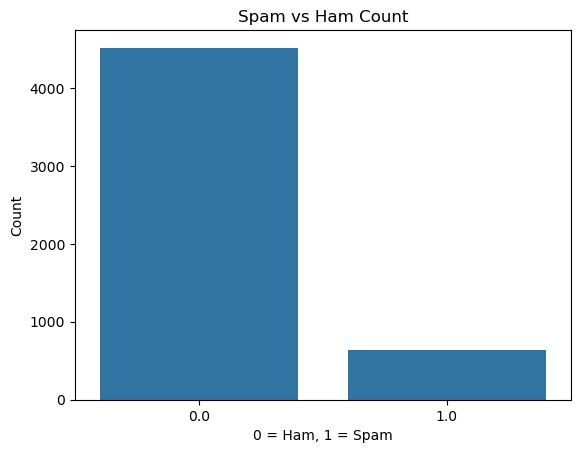

In [29]:
# EDA Graphs( explanatory data analysis)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Count")
plt.xlabel("0 = Ham, 1 = Spam")
plt.ylabel("Count")
plt.show()

# Shows how many spam vs normal emails
# Usually ham > spam

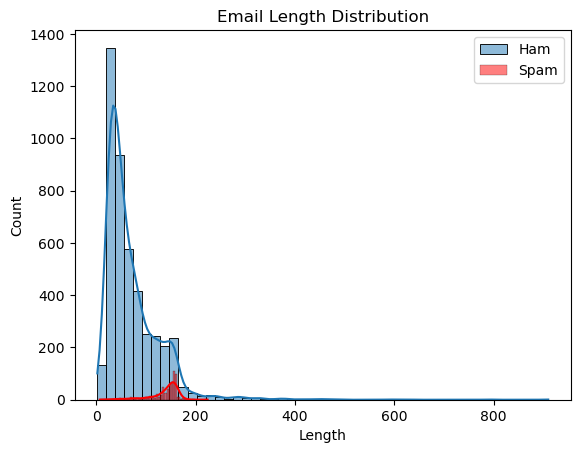

In [30]:
# Email Length Distirbution -> Spam emails are often shorter or repetitive
df['length'] = df['text'].apply(len)

sns.histplot(df[df['label']==0]['length'], bins=50, label='Ham', kde=True)
sns.histplot(df[df['label']==1]['length'], bins=50, color='red', label='Spam', kde=True)

plt.legend()
plt.title("Email Length Distribution")
plt.xlabel("Length")
plt.show()

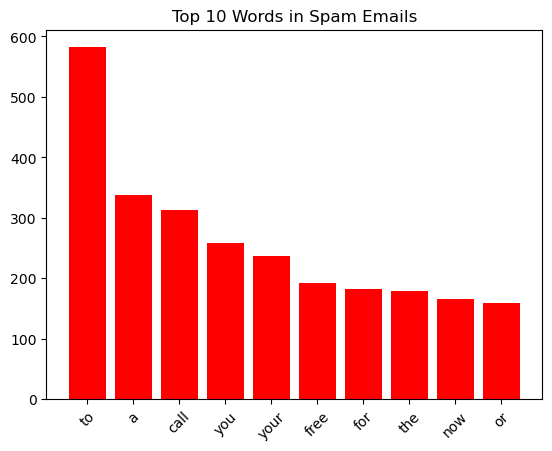

In [31]:
# Most Common Words (Spam)

from collections import Counter
spam_words = " ".join(df[df['label']==1]['text']).split()
common_spam = Counter(spam_words).most_common(10)
words = [i[0] for i in common_spam]
counts = [i[1] for i in common_spam]

plt.bar(words, counts, color='red')
plt.title("Top 10 Words in Spam Emails")
plt.xticks(rotation=45)
plt.show()

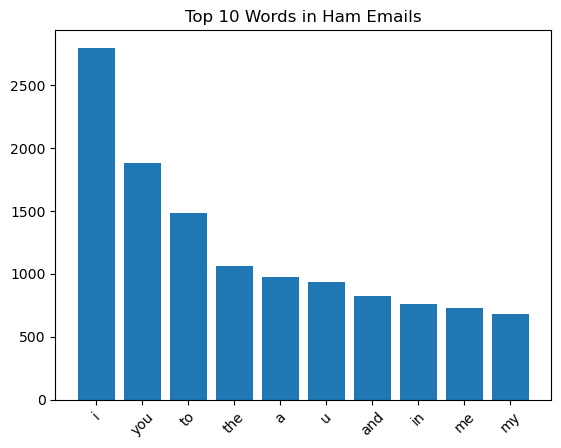

In [32]:
# Most Common Words (Ham)

ham_words = " ".join(df[df['label']==0]['text']).split()
common_ham = Counter(ham_words).most_common(10)
words = [i[0] for i in common_ham]
counts = [i[1] for i in common_ham]

plt.bar(words, counts)
plt.title("Top 10 Words in Ham Emails")
plt.xticks(rotation=45)
plt.show()

In [34]:
#   Testing function 
from sklearn.feature_extraction.text import TfidfVectorizer
def predict_spam(text):
    import re
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text_vector = vectorizer.transform([text])
    
    result = lr.predict(text_vector)[0]
    
    if result == 1:
        return "Spam "
    else:
        return "Not Spam ,its Ham"

In [35]:
email = input("Enter email: ")
print(predict_spam(email))

Enter email:  I HAVE A DATE ON SUNDAY WITH WILL!!


Not Spam ,its Ham
